## Dynamics of Cosmic Plasmas – Homework

In [2]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

from IPython.display import HTML

import time, sys, warnings

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### 1) Electron Plasma Regimes

- Debye Length:

$$\lambda_D = \sqrt{\frac{\varepsilon_0 k_B T_e}{q_e^2 n_e}} \propto T_e^{1/2} n_e^{-1/2}$$

- Debye Number:

$$N_D = \tfrac{4}{3} \pi \lambda_D^3 n_e = \sqrt{\frac{16 \pi^2 \varepsilon_0^3 k_B^3 T_e^3}{9 q_e^6 n_e}} \propto T_e^{3/2} n_e^{-1/2}$$

- Fermi Temperature:

$$ \Theta_F = \frac{T_F}{T_e} = \frac{E_F}{k_B T_e} = \frac{\hbar^2}{2k_B m_e T_e} \sqrt[\scriptstyle 3 \,]{9\pi^4 n_e^2} \propto T_e^{-1} n_e^{2/3}$$

- Plasma Freqency:

$$ \omega_{pe} = \sqrt{\frac{q_e^2 n_e}{\varepsilon_0 m_e}} \qquad n_e = \frac{\varepsilon_0 m_e \omega_{pe}^2}{q_e^2}$$

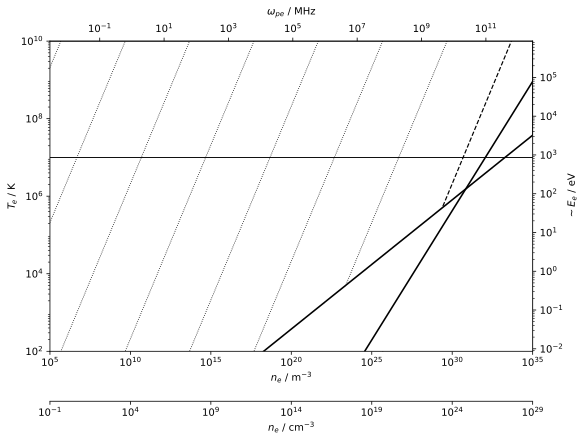

In [4]:
# Implementation

qe = 1.60217663e-19
me = 9.1093837e-31
kB = 1.38064852e-23
hbar = 1.05457182e-34
eps0 = 8.8541878188e-12

def Te_isoradius(ne, lD):
    return lD**2 * qe**2 * ne / (eps0 * kB)

def Te_isocoupling(ne, nD):
    return (nD**2 * 9 * qe**6 * ne / (16 * np.pi**2 * eps0**3 * kB**3))**(1/3)

def Te_isodegeneracy(ne, thF):
    return hbar**2 * (3 * np.pi**2 * ne)**(2/3) / (2 * kB * me * thF)

fig, ax = plt.subplots(figsize=(8,6))

n = np.logspace(5, 35, 1000)

ax.plot(n, Te_isoradius(n, 1e-10), 'k--', lw=1.2, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-8), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-6), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+0), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isocoupling(n, 1), 'k-', lw=1.6, zorder=3)
ax.plot(n, Te_isodegeneracy(n, 1), 'k-', lw=1.6, zorder=3)

ax.fill_between(n, Te_isocoupling(n, 1), color='w', zorder=2)

ax.plot([1e4, 1e36], [1e7, 1e7], 'k-', lw=0.9, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e5, 1e35)
ax.set_ylim(1e2, 1e10)

ax.set_xticks(np.logspace(5, 35, 7))
ax.set_yticks(np.logspace(2, 10, 5))

ax.set_xlabel(r'$n_e$ / m$^{-3}$')
ax.set_ylabel(r'$T_{\! e}$ / K')

bottom = ax.secondary_xaxis('bottom', functions=(lambda x: x * 1e-6, lambda x: x * 1e+6))
bottom.set_xlabel(r'$n_e$ / cm$^{-3}$')
bottom.set_xticks(np.logspace(-1, 29, 7))
bottom.spines['bottom'].set_position(('outward', 50))

top = ax.secondary_xaxis('top', functions=(lambda x: np.sqrt(x * qe**2 / (eps0 * me)) * 1e-6 / (2 * np.pi), lambda x: eps0 * me * (x * 1e6 * 2 * np.pi)**2 / (qe**2)))
top.set_xlabel(r'$\omega_{pe}$ / MHz', labelpad=10)
top.set_xticks(np.logspace(-1, 11, 7))

side = ax.secondary_yaxis('right', functions=(lambda x: x * kB / qe, lambda x: x / kB * qe))
side.set_ylabel(r'$\sim E_e$ / eV')

plt.show()
plt.close()

### 2) Saha Ionization Parameter